In [12]:
import numpy as np
import matplotlib.pyplot as plt
import numba

plt.style.use("aslak")
import pandas as pd
from density_core import DensityCore
from grinsted_firn_model import *

S51 = DensityCore.load("_prepared_data/S5-1hxct_density_core.pkl")
S52 = DensityCore.load("_prepared_data/S5-2adj_density_core.pkl")
EG = DensityCore.load("_prepared_data/EGRIP_density_core.pkl")

cores = [S51, S52, EG]
import pandas as pd

flowline_S51 = pd.read_parquet("_prepared_data/S5-1hxct_backtrajectory.parquet")
flowline_S52 = pd.read_parquet("_prepared_data/S5-2adj_backtrajectory.parquet")
flowline_EG = pd.read_parquet("_prepared_data/EGRIP_backtrajectory.parquet")

flowlines = [flowline_S51, flowline_S52, flowline_EG]
for ii in range(len(flowlines)):
    # downsample and order for modelling
    flowline = flowlines[ii]
    # keepers = flowline.t % (5 + 0 * (flowline.t / 200).astype(int)) == 0
    # flowline = flowline.loc[keepers]
    flowline.t = -flowline.t * 1.0
    flowlines[ii] = flowline.sort_values(by="t")

steadystate = pd.read_parquet("_output/steadystate_fit.parquet")

In [13]:
# parameterisation of a and nu.

if True:

    @numba.njit
    def ab_from_m(rho, m):
        a_min, a600, slope600, a300, slope300, rhoc, alpha = m
        rhat = rho / rhoi
        duvacrow = (1 + (2 / 3) * (1 - rhat)) * (rhat ** (-1.5))
        a = a_min * duvacrow + a600 * np.exp(slope600 * (rho - 600)) * 1 + a300 * np.exp(slope300 * (rho - 300))
        nu = sigmoidal_poisson(rho, rhoc=rhoc, alpha=alpha)
        b = poisson_to_b(nu, a)
        return a, b

    m0 = np.array([0.1, 18.05, -15.78652 / 917, 180, -0.04, 400, 2])
    m0 = np.array([0.1, 1, -0.015, 10000, -0.05, 700, 1.5])  # closer to steady state fit.
    m0 = np.array([1, 2.5, -0.015, 50000, -0.1, 700, 1.5])  # closer to previous fit.
    # m0 = np.array([7.64450290e-01, 2.45370533e00, -1.60778514e-02, 5.83517792e04, -1.01567484e-01, 6.43510988e02, 1.21261036e00])
    mbounds = np.array(([0.001, 10], [0.01, 100], [m0[2] * 10, 0], [1, 100000], [-1, 0], [0, 1000], [0.1, 4])).T

test = ab_from_m(900, m0)

In [17]:
if True:
    from scipy.interpolate import make_interp_spline
    from numba_spline import spline_eval

    @numba.njit
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))

    @numba.njit
    def inverse_sigmoid(y):
        return np.log(y / (1 - y))

    N = 20
    k = 3
    rho = np.linspace(300, 917, N)

    loga = np.log(a_fun(rho))
    tnu = inverse_sigmoid(sigmoidal_poisson(rho) * 1.999)
    loga_spl = make_interp_spline(rho, loga, k=k, bc_type=([(1, 0.0)], [(1, 0.0)]))
    tnu_spl = make_interp_spline(rho, tnu, k=k, bc_type=([(1, 0.0)], [(1, 0.0)]))
    # extract t and k so that we can call splev ... necessary for numba.
    loga_t, loga_k = loga_spl.t, loga_spl.k
    tnu_t, tnu_k = tnu_spl.t, tnu_spl.k

    Nspline_cs = len(loga_spl.c)

    # ensure monotonic
    for ii in range(1, len(loga_spl.c)):
        loga_spl.c[ii] = np.min(loga_spl.c[ii - 1 : ii + 1])

    @numba.njit
    def ab_from_m(rho, m):
        ca = m[:Nspline_cs]
        cnu = m[Nspline_cs:]
        # loga_spl.c = ca
        # a = np.exp(loga_spl(rho))
        a = np.exp(spline_eval(rho, loga_t, ca, loga_k))
        # tnu_spl.c = cnu
        # nu = sigmoid(tnu_spl(rho)) / 2
        nu = sigmoid(spline_eval(rho, tnu_t, cnu, tnu_k)) / 2
        b = poisson_to_b(nu, a)
        return a, b

    m0 = np.concatenate([loga_spl.c, tnu_spl.c])

    # plt.plot(m0)

ab_from_m(np.array([300]), m0)

(array([3158.27284423]), array([2975.759886]))

In [20]:
rho_surf = 330


@numba.njit
def nonsteadyfirnmodel(tyr, e1, e2, bdot, T_celsius, rho_surf, m):
    A = A_fun(T_celsius + 273.15)

    n = len(tyr)

    # outputs
    dM = np.zeros_like(tyr)  # the layer mass per m2 --- e.g. mass should be "lost" if there is horiz flow divergence.
    rho = np.zeros_like(tyr)
    # todo age of layer!
    dt = (tyr[1] - tyr[1]) * sec_per_year
    for tix in range(len(tyr)):
        ix = len(tyr) - tix - 1  # this is the surface index
        # add a new layer of snow
        dM[ix] = bdot * dt / sec_per_year  #
        rho[ix] = rho_surf
        if tix == 0:
            continue
        dt = (tyr[tix] - tyr[tix - 1]) * sec_per_year

        # only work on the indices below the surface but above solid ice
        rhoterm = rhoi - rho[ix + 1 :]
        bottom_index = np.flatnonzero(np.append(rhoterm, 0) == 0)[0]
        rhoterm = rhoterm[:bottom_index]
        curslice = slice(ix + 1, ix + 1 + bottom_index)
        # curslice = slice(ix + 1, -1)

        # update layers below
        sigma_zz = -np.cumsum(dM[ix : ix + bottom_index]) * g  # the mass of the deepest layer does not compress anything.
        # sigma_zz = -np.cumsum(dM[ix:-2]) * g  # the mass of the deepest layer does not compress anything.
        a, b = ab_from_m(rho[curslice], m)
        # ezz = np.zeros_like(sigma_zz)
        # for iz in range(len(ezz)):
        #    ezz[iz] = leastsquares_ezz(sigma_zz[iz], a[iz], b[iz], A, e1[tix], e2[tix])
        #   ezz[iz] = gagliardini_ezz(sigma_zz[iz], a[iz], b[iz], A, e1[tix], e2[tix])
        # ezz = gagliardini_ezz_vec(sigma_zz, a, b, A, e1[tix], e2[tix])
        ezz = gagliardini_ezz_vec2(sigma_zz, a, b, A, e1[tix], e2[tix])  # faster?

        # what is Drho/Dt:

        DrhoDt = -rho[curslice] * (e1[tix] + e2[tix] + ezz)  # snapshot balance equation
        dM[ix + 1 :] = dM[ix + 1 :] * np.exp(-dt * (e1[tix] + e2[tix]))  # units sec per year...
        rho[curslice] = rhoi - rhoterm * np.exp(-DrhoDt * dt / rhoterm)  # herron-langway style updating rule
        # r0 = rho[curslice]
        # rho[curslice] = -(r0 * rhoi) / (np.exp(-(-DrhoDt * rhoi * dt) / (r0 * (r0 - rhoi - 1))) * (r0 - rhoi) - r0)

    dH = dM / rho
    z = np.cumsum(dH) - dH / 2
    return z, rho, dM

In [22]:
def model_coreindex(coreidx=0, m=m0):
    flowline = flowlines[coreidx]
    core = cores[coreidx]
    t = flowline.t.values * 1.0

    e1 = flowline.e1.values / sec_per_year
    e2 = flowline.e2.values / sec_per_year
    # e1 = e1 * 0 + core.e1 / sec_per_year
    # e2 = -e1 * 0 + core.e2 / sec_per_year
    bdot = core.bdot

    z, rho, dM = nonsteadyfirnmodel(t, e1, e2, bdot, core.T, rho_surf, m)
    return z, rho, dM


def core_deviance(coreidx=0, m=m0):
    core = cores[coreidx]
    z, rho, dM = model_coreindex(coreidx, m)
    return np.interp(core.raw_z, z, rho) - core.raw_rho


def model_penalty_term(m):
    ca = m[:Nspline_cs]
    cnu = m[Nspline_cs:]
    ok = 0
    if np.any(ca[1:] > ca[:-1]):
        # if any coeffs violating monotonic
        ok = np.inf
    return np.concatenate([np.diff(ca, 2), np.diff(cnu, 2), ok])


def full_deviance(m):
    return np.concat([core_deviance(coreidx, m) for coreidx in range(len(cores))])


z, rho, dM = model_coreindex(0, m0)
import timeit

if False:
    # newafun, newbfun = abfun_from_m(m0)
    cores[0].plot(show_raw=True)
    plt.plot(rho, z)
    ssz, ssrho = density_profile(
        cores[0].T + 273.15,
        1,
        cores[0].bdot / sec_per_year,
        rho_s=350,
        e1=cores[0].e1 / sec_per_year,
        e2=cores[0].e2 / sec_per_year,
        A_fun=A_fun,
        a_fun=newafun,
        b_fun=newbfun,
    )
    plt.plot(ssrho, ssz, "--")
model_coreindex(1, m0)
timeit.timeit(lambda: model_coreindex(0, m0), number=10) / 10

0.696252739999909

In [10]:
from scipy.optimize import least_squares

# fscale_estimate = np.std(np.diff(cores[coreidx].raw_rho)/np.sqrt(2))

res = least_squares(full_deviance, m0, loss="soft_l1", f_scale=10)  # , bounds=mbounds)  # , )

In [11]:
m = res.x
# np.round((m - mbounds[0,:])*100/np.diff(mbounds,axis=0))
res.x

array([ 8.05803600e+00,  8.97306308e+00,  8.09432820e+00,  5.18506014e+00,
        4.37012280e+00,  3.94068847e+00,  4.54797575e+00,  2.23959740e+00,
        3.18595539e+00,  2.06580134e+00,  3.37185244e+00,  2.29299430e+00,
        1.21185129e+00,  4.55776146e-01, -3.43541972e-01,  3.13921335e-01,
       -8.98819751e-02, -8.34325582e-02, -1.62305792e+00, -2.99327308e+00,
       -2.97759089e+00,  8.85441086e-01, -9.29818065e-01, -1.30235198e+00,
       -6.90981195e-01, -1.59769802e-03, -1.42796270e+00,  3.59696929e-01,
       -5.67767645e-01, -2.77625248e-01,  3.12727142e-01,  5.50761987e-01,
        2.14353657e+00,  1.67699015e+00,  4.26822805e-01, -2.55724845e-02,
       -8.09354006e-01,  9.65518146e-01,  7.60879580e-01,  1.37327666e+00,
        4.50001350e-02, -1.56964583e+00,  3.39981434e+00,  5.85217852e+00])

In [12]:
res

     message: `xtol` termination condition is satisfied.
     success: True
      status: 3
         fun: [-4.787e+00 -3.611e+00 ... -9.295e+00 -3.645e+00]
           x: [ 8.058e+00  8.973e+00 ...  3.400e+00  5.852e+00]
        cost: 15776.042598176286
         jac: [[ 3.743e-04  4.042e-01 ...  0.000e+00  0.000e+00]
               [ 3.584e-05  1.295e+00 ...  0.000e+00  0.000e+00]
               ...
               [ 5.935e-07  2.689e-03 ... -2.313e+00 -2.528e-01]
               [ 8.622e-07  3.875e-03 ... -3.503e+00 -4.222e-01]]
        grad: [-3.412e-03 -1.073e+01 ...  7.991e+01  3.212e+01]
  optimality: 158.4389645788189
 active_mask: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
        nfev: 41
        njev: 26

In [13]:
afun, bfun = abfun_from_m(m)

array([ 8.05803600e+00,  8.97306308e+00,  8.09432820e+00,  5.18506014e+00,
        4.37012280e+00,  3.94068847e+00,  4.54797575e+00,  2.23959740e+00,
        3.18595539e+00,  2.06580134e+00,  3.37185244e+00,  2.29299430e+00,
        1.21185129e+00,  4.55776146e-01, -3.43541972e-01,  3.13921335e-01,
       -8.98819751e-02, -8.34325582e-02, -1.62305792e+00, -2.99327308e+00,
       -2.97759089e+00,  8.85441086e-01, -9.29818065e-01, -1.30235198e+00,
       -6.90981195e-01, -1.59769802e-03, -1.42796270e+00,  3.59696929e-01,
       -5.67767645e-01, -2.77625248e-01,  3.12727142e-01,  5.50761987e-01,
        2.14353657e+00,  1.67699015e+00,  4.26822805e-01, -2.55724845e-02,
       -8.09354006e-01,  9.65518146e-01,  7.60879580e-01,  1.37327666e+00,
        4.50001350e-02, -1.56964583e+00,  3.39981434e+00,  5.85217852e+00])

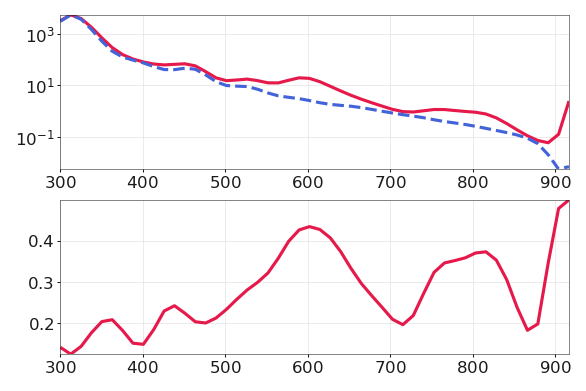

In [14]:
rho = np.linspace(300, 917)
plt.subplot(2, 1, 1)
plt.semilogy(rho, afun(rho))
plt.semilogy(rho, bfun(rho), "--")
plt.subplot(2, 1, 2)
plt.plot(rho, poisson_from_ab(afun(rho), bfun(rho)))
m

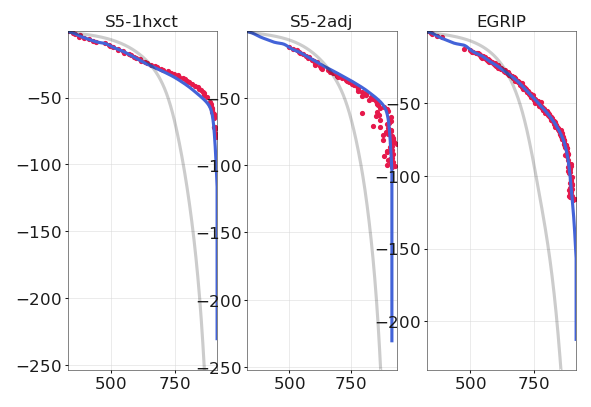

In [15]:
for coreidx in range(3):
    plt.subplot(1, 3, coreidx + 1)
    plt.plot(cores[coreidx].raw_rho, -cores[coreidx].raw_z, ".")
    z, rho, dM = model_coreindex(coreidx, m)
    plt.plot(rho, -z)
    z, rho, dM = model_coreindex(coreidx, m0)
    plt.plot(rho, -z, "k", alpha=0.2)

    plt.title(cores[coreidx].site_name)

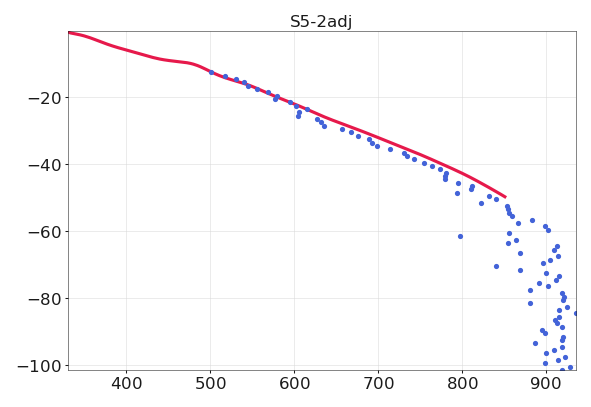

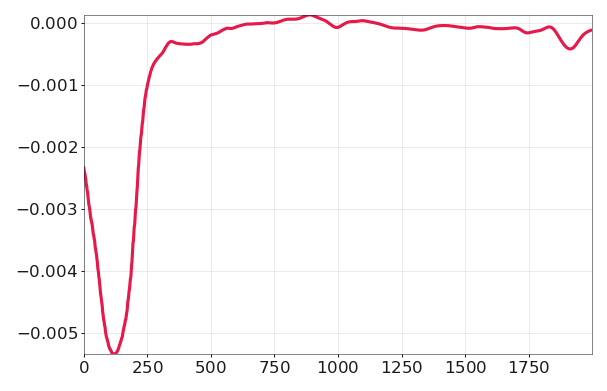

In [16]:
coreidx = 1
z, rho, dM = model_coreindex(coreidx, m)
plt.plot(rho[z < 50], -z[z < 50])
plt.plot(cores[coreidx].raw_rho, -cores[coreidx].raw_z, ".")
plt.title(cores[coreidx].site_name)

plt.figure()
plt.plot(flowlines[coreidx].e2)

In [17]:
print(res.x / m0)
print("a_min, a600, slope600, a300, slope300, rhoc, alpha = m")

[ 1.00003170e+00  1.11358990e+00  1.09202066e+00  7.44673971e-01
  6.85570864e-01  6.76715770e-01  8.64289596e-01  4.76143527e-01
  7.68736138e-01  5.76162893e-01  1.11421457e+00  9.29158313e-01
  6.35691931e-01  3.36034696e-01 -4.49912817e-01  9.50264151e-01
 -2.72079688e-01 -3.59332481e-01 -1.05200524e+01 -3.37710352e+01
             inf             inf  1.00011191e+00  1.40080923e+00
  1.22473274e+00  4.88083295e-03  7.36857221e+01  1.37500993e+00
 -1.04033603e+00 -3.35036722e-01  2.80460192e-01  3.91309962e-01
  1.25390508e+00  8.28108367e-01  1.80905909e-01 -9.40508835e-03
 -2.59964887e-01  2.71529557e-01  1.87027699e-01  2.93097119e-01
  8.21403194e-03 -2.39287079e-01  4.47320312e-01  7.69982728e-01]
a_min, a600, slope600, a300, slope300, rhoc, alpha = m


C:\Users\ag\AppData\Local\Temp\ipykernel_22944\3428577280.py:1: RuntimeWarning: divide by zero encountered in divide
  print(res.x / m0)


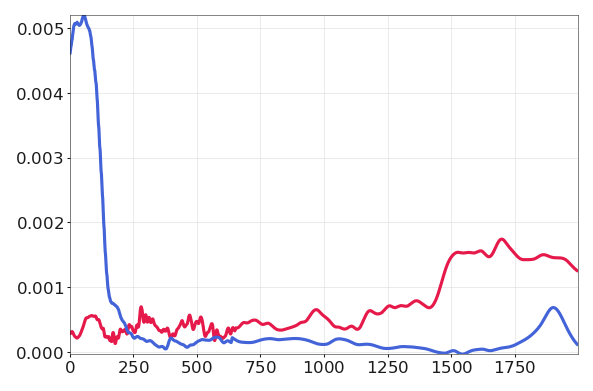

In [18]:
flowline = flowlines[2]
plt.plot(flowline.e1)
flowline = flowlines[0]
plt.plot(flowline.e1)